# Demo implementation of all algorithms

In [1]:
# import necessary libraries
import numpy as np
from simulate_data import simulate_views

## Simulate data

In [108]:
matrices = simulate_views(n=500, num_genes=10, M_C=10, M_Z=3, rank=3, seed=0)
print(matrices.keys())

# drop one (multicollinear) column of Z and add intercept to Z 
Z = np.c_[np.ones(matrices['Z'][:,1:].shape[0]), matrices['Z'][:,1:]]

dict_keys(['G', 'C', 'Z', 'W_C', 'W_G', 'H_G', 'H_C', 'U_G', 'U_C', 'true_Z'])


## Run SCoNE

In [87]:
from algorithms.SCoNE import SCoNE_parallel

factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],matrices['C'],Z, rank=3,
    alpha=max(matrices['G'].max(),matrices['C'].max())**2,lambda_H_G=1e-4, lambda_H_C=1e-4, lambda_Gloss=1,   # regularization parameters
    num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type='kl_div', # in 'kl_div',  'fro' or None
)

In [118]:
factor_matrices['H_C'].shape

(10, 2)

In [147]:
from algorithms.SCoNE import SCoNE_parallel  # todo: move to other notebook
from evaluation.reconstruction_evaluation import best_permutation_similarity
import pandas as pd

def get_col_cosine_sim(A,B):
    dot = A.T @ B

    normA = np.linalg.norm(A, axis=0)   # length p
    normB = np.linalg.norm(B, axis=0)   # length q

    denom = np.outer(normA, normB)
    denom[denom == 0] = 1   # prevent divide-by-zero

    cos_sim = dot / denom
    return cos_sim.item() if cos_sim.size == 1 else cos_sim

matrices = simulate_views(n=1000, num_genes=100, M_C=10, M_Z=3, rank=3, seed=0, 
                          Z_noise=10, ZU_weight=0.5)
print(matrices.keys())

# drop one (multicollinear) column of Z and add intercept to Z 
Z = np.c_[np.ones(matrices['Z'][:,1:].shape[0]), matrices['Z'][:,1:]]

results = []
results_columns = ['rank','variable','value']
for rank in range(1,7):
    print(rank)
    factor_matrices, loss_function = SCoNE_parallel(
        matrices['G'],None, Z, rank=rank,
        alpha=max(matrices['G'].max(),matrices['C'].max())**2,lambda_H_G=1e-4, lambda_H_C=1e-4, lambda_Gloss=1,   # regularization parameters
        num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type=None, # in 'kl_div',  'fro' or None
    )

    results.append([rank,'Wpred_W approx',np.mean(np.max(get_col_cosine_sim(factor_matrices['W'],matrices['W_G']),axis=0))])
    results.append([rank,'cos W_Z',np.max(get_col_cosine_sim(factor_matrices['W'],matrices['true_Z'][:,0]))])
    results.append([rank,'cos UGpred_UG',get_col_cosine_sim(factor_matrices['U_G'][:,0],matrices['U_G'][:,0])])
    results.append([rank,'UG_pred_norm',np.linalg.norm(factor_matrices['U_G'][:,0])])
    results.append([rank,'cos HGpred_UG',np.max(get_col_cosine_sim(factor_matrices['H_G'],matrices['U_G'][:,0].reshape(-1, 1)))])

dict_keys(['G', 'C', 'Z', 'W_C', 'W_G', 'H_G', 'H_C', 'U_G', 'U_C', 'true_Z'])
1
2
3
4
5
6


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 10 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 2 rows containing missing values.


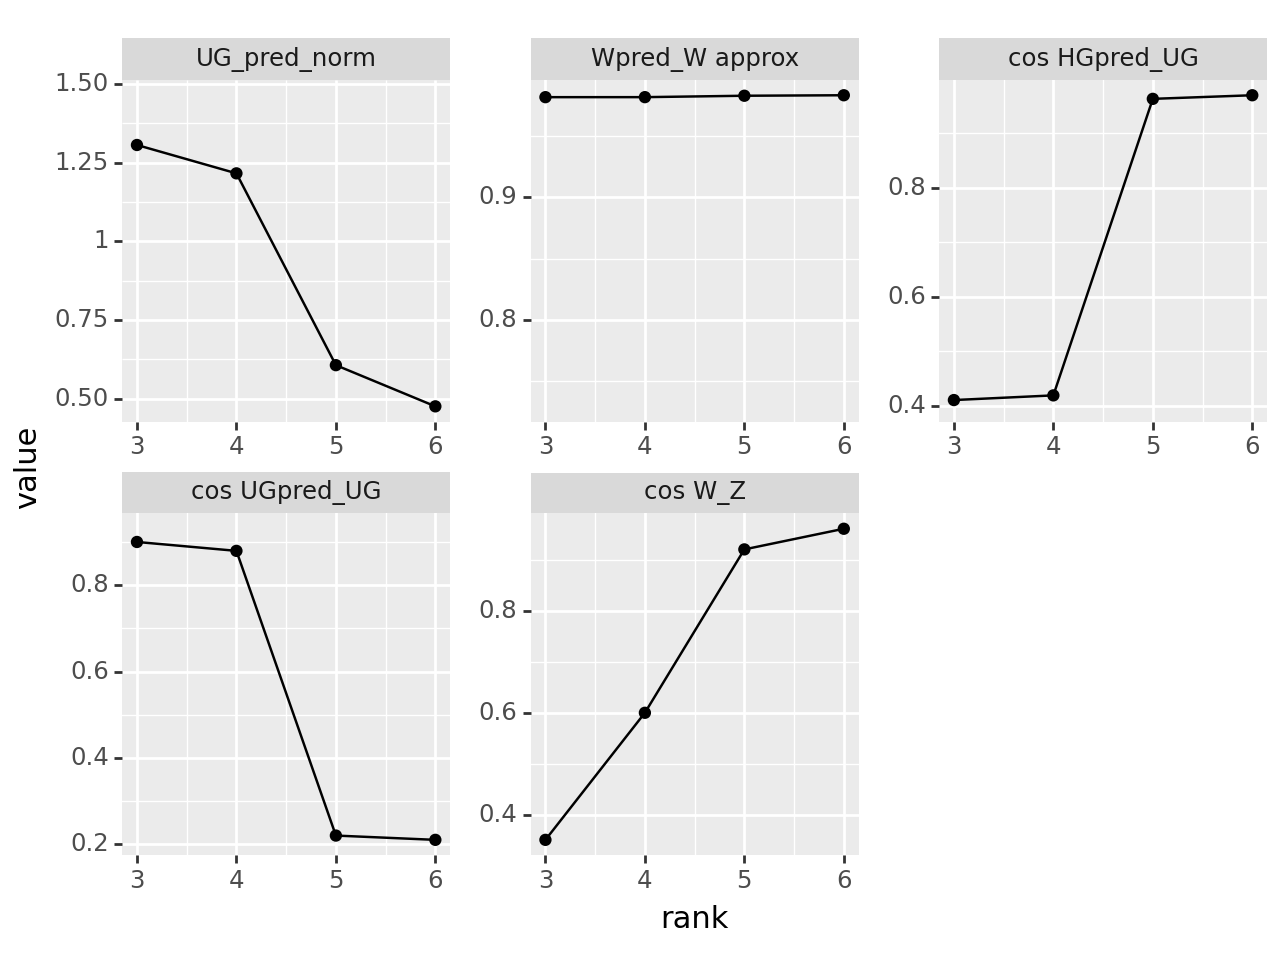

In [149]:
results_df = pd.DataFrame(results, columns=results_columns)
from plotnine import *
p = (ggplot(results_df, aes(x='rank',y='value'))
       + geom_point()
       + geom_line()
       + xlim(3,6)
       + facet_wrap('variable',scales='free'))
print(p)

In [6]:
from evaluation.reconstruction_evaluation import best_permutation_similarity

best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.813210380061865

In [71]:
best_permutation_similarity(matrices['U_G'],factor_matrices['U_G'])

0.695304863664004

## Run SCoNE (Fro)

In [72]:
factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],matrices['C'],matrices['Z'], rank=3,
    alpha=max(matrices['G'].max(),matrices['C'].max())**2,lambda_H_G=1e-4, lambda_H_C=1e-4, lambda_Gloss=1,         # regularization parameters
    num_init=10,init='nndsvda',G_loss_type='fro', C_loss_type='fro', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.7127066270253228

## Run CoNE

In [73]:
factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],matrices['C'],matrices['Z'], rank=3,
    alpha=0,lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,         # regularization parameters
    num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type='kl_div', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.7994121517008319

## Run HNMF

In [74]:
factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],matrices['C'],None, rank=3,
    alpha=0,lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,         # regularization parameters
    num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type='kl_div', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.7418505950605683

## Run HNMF (res)

In [75]:
from algorithms.SCoNE import proj_nonneg

C_resid = proj_nonneg(matrices['C'] - matrices['Z'] @ np.linalg.lstsq(matrices['Z'], matrices['C'],rcond=None)[0])
G_resid = proj_nonneg(matrices['G'] - matrices['Z'] @ np.linalg.lstsq(matrices['Z'], matrices['G'],rcond=None)[0])

factor_matrices, loss_function = SCoNE_parallel(
    G_resid,C_resid,None, rank=3,
    alpha=0,lambda_H_G=0, lambda_H_C=0, lambda_Gloss=1,         # regularization parameters
    num_init=10,init='nndsvda',G_loss_type='fro', C_loss_type='fro', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.7007339385522637

## Run C-CoNE

In [76]:
factor_matrices, loss_function = SCoNE_parallel(
    None,matrices['C'],matrices['Z'], rank=3,
    num_init=10,init='nndsvda',G_loss_type=None, C_loss_type='kl_div', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.6959518784798652

## Run G-CoNE

In [77]:
factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],None,matrices['Z'], rank=3,
    num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type=None, # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.6945459226410914

## Run C-NMF

In [78]:
factor_matrices, loss_function = SCoNE_parallel(
    None,matrices['C'],None, rank=3,
    num_init=10,init='nndsvda',G_loss_type=None, C_loss_type='kl_div', # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.6666500625689084

## Run G-NMF

In [79]:
factor_matrices, loss_function = SCoNE_parallel(
    matrices['G'],None,None, rank=3,
    num_init=10,init='nndsvda',G_loss_type='kl_div', C_loss_type=None, # in 'kl_div',  'fro' or None
)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.6487308422655256

## Run RGWAS

In [81]:
import os
from algorithms.RGWASWrapper import RGWASWrapper

cwd = os.getcwd()
parent_dir = os.path.dirname(os.getcwd())
# NOTE: important to save as float64 so read correctly in R
np.save(f'{parent_dir}/example_data/G',matrices["G"].astype(np.float64)) 
np.save(f'{parent_dir}/example_data/C',matrices["C"].astype(np.float64))
np.save(f'{parent_dir}/example_data/Z',matrices["Z"][:,1:].astype(np.float64)) # drop one column to avoid multicollinearity
factor_matrices, loss_function = RGWASWrapper(
    r_path='/gpfs/commons/home/anewbury/miniconda/bin/Rscript', # REPLACE WITH CORRECT Rscript path
    G_path=f'{parent_dir}/example_data/G.npy',
    C_path=f'{parent_dir}/example_data/C.npy',
    Z_path=f'{parent_dir}/example_data/Z.npy',
    rank=3, num_init=10)
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.3583231075430976

## Run MVBC

In [82]:
import algorithms.MVBCWrapper as MVBCWrapper
import importlib
importlib.reload(MVBCWrapper)

factor_matrices, loss_function = MVBCWrapper.MVBCWrapper(
    G_path=f'{parent_dir}/example_data/G.npy', C_path=f'{parent_dir}/example_data/C.npy', 
    rank=3, lambda_W=1, lambda_H_G=1, lambda_H_C=1,  
    r_path='/gpfs/commons/home/anewbury/miniconda/bin/Rscript') # REPLACE WITH CORRECT Rscript path
best_permutation_similarity(matrices['W_C'],factor_matrices['W'])

0.42211615474295544